<a href="https://colab.research.google.com/github/Altium/Preditive-AI/blob/main/Final_Regression_File.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Importing Packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
# 1. Importação do CSV de treinamento base, futuramente trocar disso para o modelo de API GEE ou Sentinel 2
url = 'https://raw.githubusercontent.com/Altium/Preditive-AI/refs/heads/main/maharashtra_Rice_CropR1.csv'

# 2. Chame a variável 'url' dentro dos parênteses (sem aspas)
dataset = pd.read_csv(url)

In [ ]:
#View the dataset
dataset

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Rainfall,MaxTemp,Production,Productivity
0,Maharashtra,AHMEDNAGAR,1997,Kharif,Rice,5900,372.8,31.96,7200,1.22
1,Maharashtra,AKOLA,1997,Kharif,Rice,2900,587.0,32.79,1600,0.55
2,Maharashtra,AMRAVATI,1997,Kharif,Rice,9500,836.3,33.15,5800,0.61
3,Maharashtra,AURANGABAD,1997,Kharif,Rice,1100,751.3,32.86,1200,1.09
4,Maharashtra,BEED,1997,Kharif,Rice,3400,764.1,33.20,1700,0.50
...,...,...,...,...,...,...,...,...,...,...
921,Maharashtra,SOLAPUR,2019,Kharif,Rice,400,454.6,32.61,100,0.25
922,Maharashtra,THANE,2019,Kharif,Rice,137500,2192.9,31.55,356800,2.59
923,Maharashtra,WARDHA,2019,Kharif,Rice,19400,890.7,33.45,31700,1.63
924,Maharashtra,WASHIM,2019,Kharif,Rice,2000,567.9,33.90,800,0.40


In [ ]:
#Shape of dataset : cotains 926 rows and 10 columns
dataset.shape

(926, 10)

# Part 1: Preparação de documentação e importação de arquivos

In [ ]:
dataset=dataset.drop(['State_Name','Crop'],axis=1)

In [ ]:
dataset

,District_Name,Crop_Year,Season,Area,Rainfall,MaxTemp,Production,Productivity
0,AHMEDNAGAR,1997,Kharif,5900,372.8,31.96,7200,1.22
1,AKOLA,1997,Kharif,2900,587.0,32.79,1600,0.55
2,AMRAVATI,1997,Kharif,9500,836.3,33.15,5800,0.61
3,AURANGABAD,1997,Kharif,1100,751.3,32.86,1200,1.09
4,BEED,1997,Kharif,3400,764.1,33.20,1700,0.50
...,...,...,...,...,...,...,...,...
921,SOLAPUR,2019,Kharif,400,454.6,32.61,100,0.25
922,THANE,2019,Kharif,137500,2192.9,31.55,356800,2.59
923,WARDHA,2019,Kharif,19400,890.7,33.45,31700,1.63
924,WASHIM,2019,Kharif,2000,567.9,33.90,800,0.40


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 926 entries, 0 to 925
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   District_Name  926 non-null    object 
 1   Crop_Year      926 non-null    int64  
 2   Season         926 non-null    object 
 3   Area           926 non-null    int64  
 4   Rainfall       926 non-null    float64
 5   MaxTemp        926 non-null    float64
 6   Production     926 non-null    int64  
 7   Productivity   926 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 58.0+ KB


In [ ]:
print(dataset['District_Name'].unique())

['AHMEDNAGAR' 'AKOLA' 'AMRAVATI' 'AURANGABAD' 'BEED' 'BHANDARA' 'BULDHANA'
 'CHANDRAPUR' 'DHULE' 'GADCHIROLI' 'GONDIA' 'HINGOLI' 'JALGAON' 'JALNA'
 'KOLHAPUR' 'LATUR' 'NAGPUR' 'NANDED' 'NANDURBAR' 'NASHIK' 'OSMANABAD'
 'PALGHAR' 'PARBHANI' 'PUNE' 'RAIGAD' 'RATNAGIRI' 'SANGLI' 'SATARA'
 'SINDHUDURG' 'SOLAPUR' 'THANE' 'WARDHA' 'WASHIM' 'YAVATMAL']


In [ ]:
#Visualizing the dataset

/tmp/ipykernel_1245/2426332555.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart=sns.countplot(x='District_Name',data=dataset,palette='Set1')
/tmp/ipykernel_1245/2426332555.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45,horizontalalignment='right',fontweight='light',


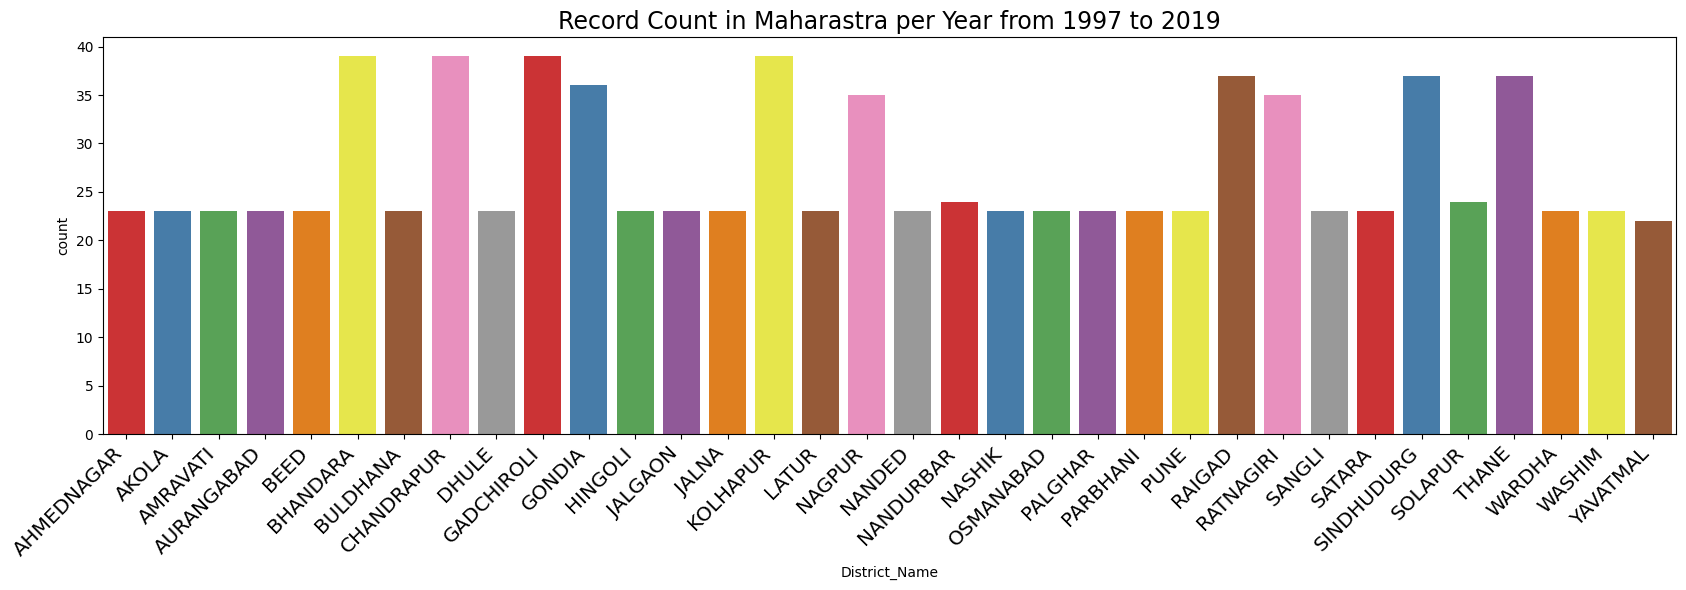

In [ ]:
plt.figure(figsize=(17,6), dpi = 100)
chart=sns.countplot(x='District_Name',data=dataset,palette='Set1')
plt.xlabel('District_Name')
chart.set_xticklabels(chart.get_xticklabels(), rotation=45,horizontalalignment='right',fontweight='light',
    fontsize='x-large')
plt.title("Record Count in Maharastra per Year from 1997 to 2019", fontsize=17)
plt.tight_layout()

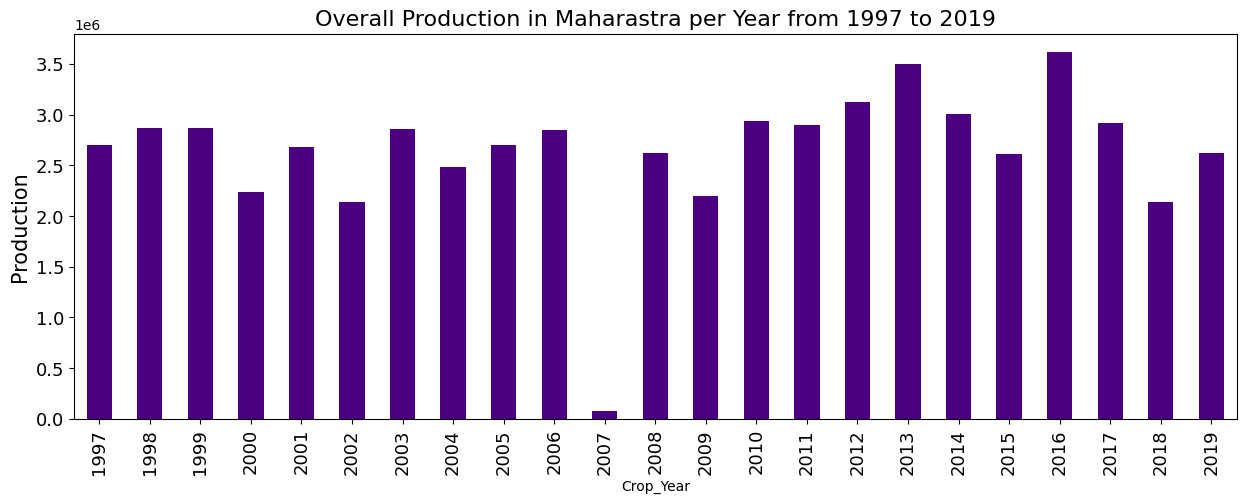

In [ ]:
by_year = dataset.groupby('Crop_Year')['Production'].sum()
# Plotting the bars

ax = by_year.plot(kind='bar', figsize=(15,5), color="indigo", fontsize=13)
ax.set_alpha(0.8)
ax.set_title("Overall Production in Maharastra per Year from 1997 to 2019", fontsize=16)
ax.set_ylabel("Production", fontsize=15)
plt.show()

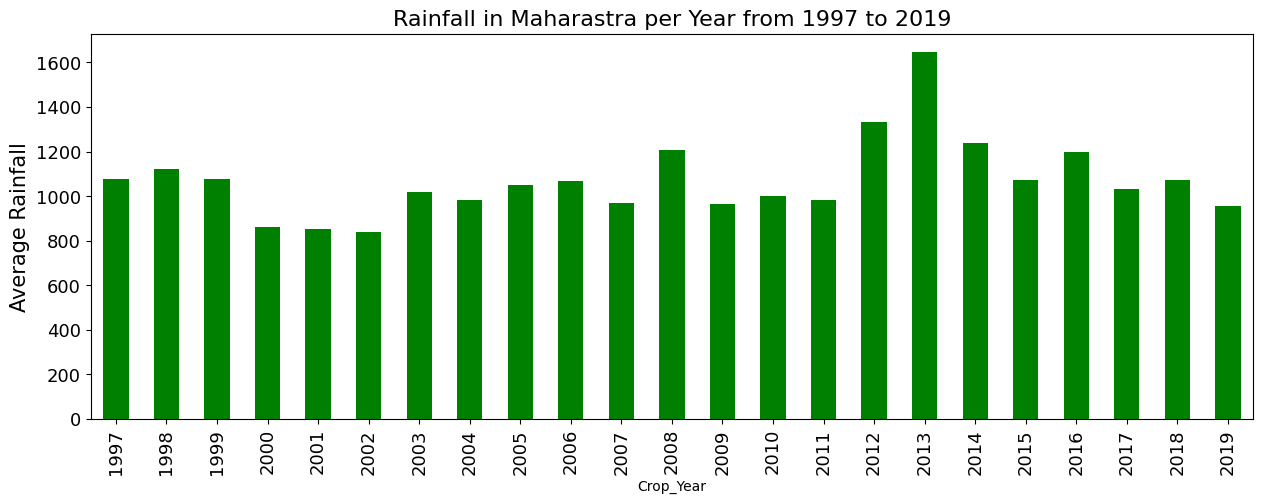

In [ ]:
by_year = dataset.groupby('Crop_Year')['Rainfall'].mean()
# Plotting the bars

ax = by_year.plot(kind='bar', figsize=(15,5), color="green", fontsize=13)
ax.set_alpha(0.8)
ax.set_title("Rainfall in Maharastra per Year from 1997 to 2019", fontsize=16)
ax.set_ylabel("Average Rainfall", fontsize=15)
plt.show()

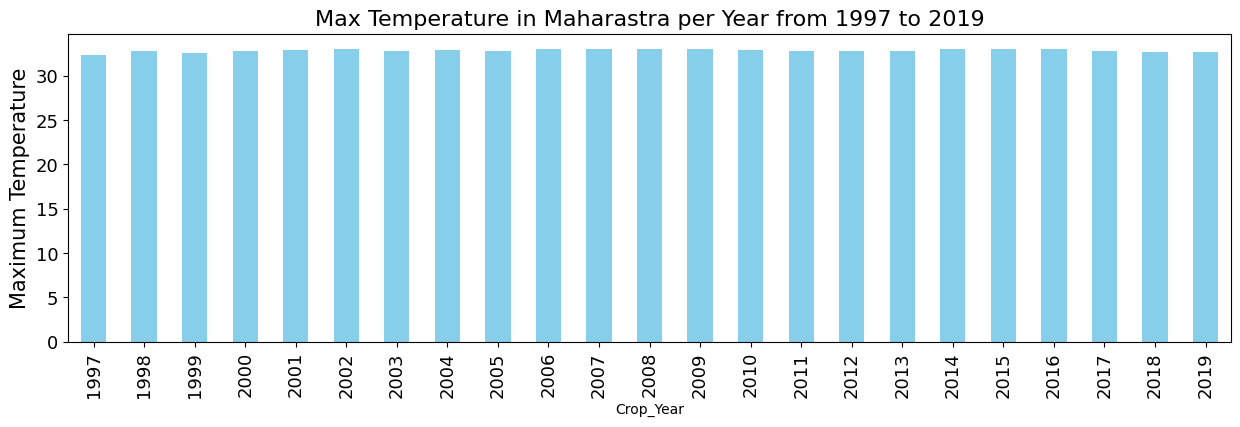

In [ ]:
by_year = dataset.groupby('Crop_Year')['MaxTemp'].mean()
# Plotting the bars

ax = by_year.plot(kind='bar', figsize=(15,4), color="skyblue", fontsize=13)
ax.set_alpha(0.8)
ax.set_title("Max Temperature in Maharastra per Year from 1997 to 2019", fontsize=16)
ax.set_ylabel("Maximum Temperature", fontsize=15)
plt.show()

In [ ]:
#Creating the correlation matrix for the features
corr_matrix=dataset.corr(numeric_only=True)
corr_matrix

,Crop_Year,Area,Rainfall,MaxTemp,Production,Productivity
Crop_Year,1.000000,0.022331,0.115690,0.041494,0.068377,-0.051912
Area,0.022331,1.000000,0.302188,-0.141118,0.902099,0.012380
Rainfall,0.115690,0.302188,1.000000,-0.340644,0.402226,0.155090
MaxTemp,0.041494,-0.141118,-0.340644,1.000000,-0.326198,-0.155617
Production,0.068377,0.902099,0.402226,-0.326198,1.000000,0.115836
Productivity,-0.051912,0.012380,0.155090,-0.155617,0.115836,1.000000


In [ ]:
mask = np.zeros_like(corr_matrix, dtype=np.bool)
mask[np.triu_indices_from(mask)]= True

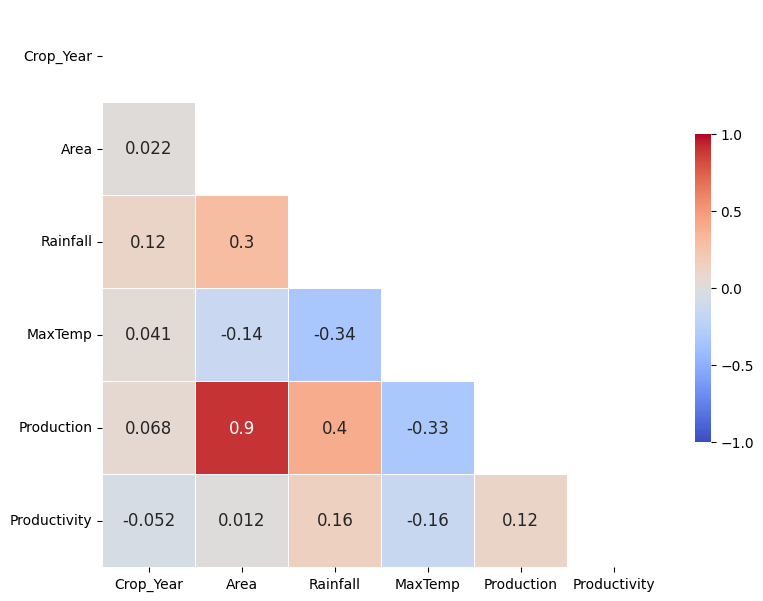

In [ ]:
f, ax = plt.subplots(figsize=(9, 10))
heatmap = sns.heatmap(corr_matrix, mask = mask,square = True,linewidths = .5, cmap = 'coolwarm', cbar_kws = {'shrink': .4, 'ticks' : [-1, -.5, 0, 0.5, 1]},vmin = -1, vmax = 1,annot = True,annot_kws = {'size': 12})
#add the column names as labels
ax.set_yticklabels(corr_matrix.columns, rotation = 0)
ax.set_xticklabels(corr_matrix.columns)
sns.set_style({'xtick.bottom': True}, {'ytick.left': True})

In [ ]:
#converting the dataframe to numpy array
data=dataset.iloc[:,:].values

In [ ]:
data

array([['AHMEDNAGAR', 1997, 'Kharif     ', ..., 31.96, 7200, 1.22],
       ['AKOLA', 1997, 'Kharif     ', ..., 32.79, 1600, 0.55],
       ['AMRAVATI', 1997, 'Kharif     ', ..., 33.15, 5800, 0.61],
       ...,
       ['WARDHA', 2019, 'Kharif     ', ..., 33.45, 31700, 1.63],
       ['WASHIM', 2019, 'Kharif     ', ..., 33.9, 800, 0.4],
       ['YAVATMAL', 2019, 'Kharif     ', ..., 33.2, 900, 0.5]],
      dtype=object)

In [ ]:
#Converting categorical data like District_Name and Season into numeric
#Encoding categorical data
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [ ]:
import pandas as pd

# Substitui TODO o bloco anterior por estas duas linhas modernas
dataset_codificado = pd.get_dummies(dataset, drop_first=True)
data = dataset_codificado.to_numpy().astype(float)

In [ ]:
data

array([[1.997e+03, 5.900e+03, 3.728e+02, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [1.997e+03, 2.900e+03, 5.870e+02, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [1.997e+03, 9.500e+03, 8.363e+02, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       ...,
       [2.019e+03, 1.940e+04, 8.907e+02, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [2.019e+03, 2.000e+03, 5.679e+02, ..., 1.000e+00, 0.000e+00,
        0.000e+00],
       [2.019e+03, 1.800e+03, 8.340e+02, ..., 0.000e+00, 1.000e+00,
        0.000e+00]])

In [ ]:
data.shape

(926, 40)

# Part 2: Separação dos dados de entrada para treino e teste.

In [ ]:
X=data[:,:-1]
y=data[:,-1]

In [ ]:
#Creating Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=101)

In [ ]:
X_train,y_train=np.array(X_train),np.array(y_train)

# Part 3: Criação do Modelo

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
#Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

In [ ]:
# Supondo que 'X' receba as colunas preditoras e 'y' receba a coluna alvo (ex: a última)
# Forçamos o tipo para float para que o DecisionTreeRegressor leia sem reclamar
X = data[:, :-1].astype(float)
y = data[:, -1].astype(float)

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# 1. Cria o modelo do zero na memória do sistema
dt_regressor = DecisionTreeRegressor()

# 2. Treina o modelo com os novos dados numéricos que preparamos
dt_regressor.fit(X_train, y_train)

# 3. Faz a predição (a linha que você estava tentando rodar)
y_pred_DT = dt_regressor.predict(X_test)

In [ ]:
import pandas as pd

# Cria o DataFrame comparando o valor Real (y_test) com o Predito (y_pred_DT)
df_comparacao = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_DT})
print(df_comparacao.head()) # Mostra as primeiras linhas da comparação

   Actual  Predicted
0     1.0        1.0
1     0.0        0.0
2     0.0        0.0
3     0.0        0.0
4     0.0        0.0


In [ ]:
print('Mean Absolute Error:',mean_absolute_error(y_test,y_pred_DT))
print('Mean squared Error:',mean_squared_error(y_test,y_pred_DT))
print('Root Mean Squared Error:',np.sqrt(mean_squared_error(y_test,y_pred_DT)))
#print('R2_Score:',r2_score(y_test, y_pred_DT))

Mean Absolute Error: 0.021505376344086023
Mean squared Error: 0.021505376344086023
Root Mean Squared Error: 0.1466471150213533


In [ ]:
decision_r2_score= r2_score(y_test, y_pred_DT)
decision_r2_score

0.8677098150782361

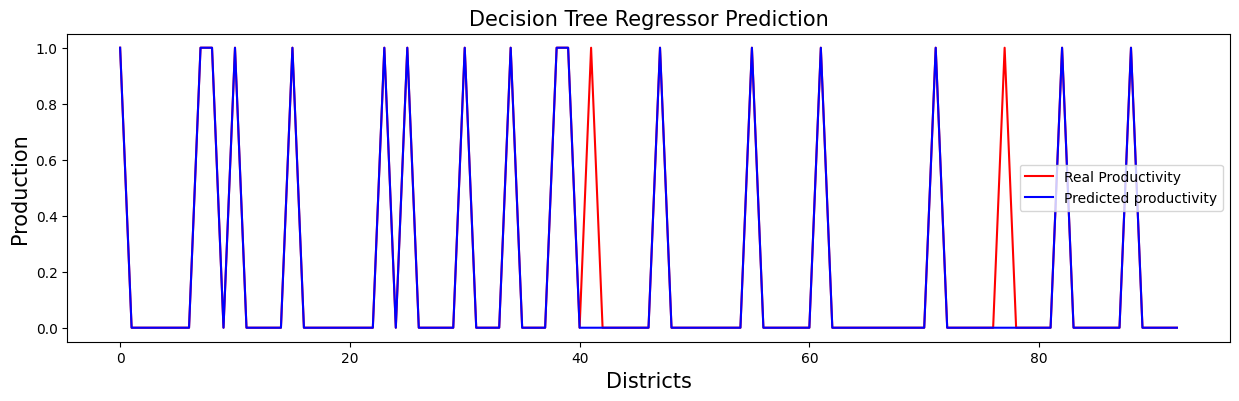

In [ ]:
# Visualising the results
plt.figure(figsize=(15,4))
plt.plot(y_test, color = 'red', label = 'Real Productivity')
plt.plot(y_pred_DT, color = 'blue', label = 'Predicted productivity')
plt.title('Decision Tree Regressor Prediction',fontsize=15)
plt.xlabel('Districts',fontsize=15)
plt.ylabel('Production',fontsize=15)
plt.legend()
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# 1. Cria o modelo KNN (K-Neighbors Regressor) na memória
knn_regressor = KNeighborsRegressor()

# 2. Treina o modelo KNN com os mesmos dados de treino
knn_regressor.fit(X_train, y_train)

# 3. Faz a predição usando o KNN
y_pred_KNN = knn_regressor.predict(X_test)

In [ ]:
# 1. Recupera da memória novamente
neigh_2 = KNeighborsRegressor()

# 2. Treina novamente
neigh_2.fit(X_train, y_train)

# 3. Predição usando o kn
y_pred_kn_2=neigh_2.predict(X_test)

In [ ]:
KNN_2=pd.DataFrame({'Actual':y_test,'Predicted':y_pred_kn_2})
KNN_2

,Actual,Predicted
0,1.0,0.4
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
88,1.0,0.8
89,0.0,0.0
90,0.0,0.0
91,0.0,0.0


In [ ]:
print('Mean Absolute Error:',mean_absolute_error(y_test,y_pred_kn_2))
print('Mean squared Error:',mean_squared_error(y_test,y_pred_kn_2))
print('Root Mean Squared Error:',np.sqrt(mean_squared_error(y_test,y_pred_kn_2)))
#print('R2_Score:',r2_score(y_test, y_pred_kn_2))

Mean Absolute Error: 0.10537634408602149
Mean squared Error: 0.06236559139784946
Root Mean Squared Error: 0.24973103811470743


In [ ]:
knn2_r2_score= r2_score(y_test, y_pred_kn_2)
knn2_r2_score

0.6163584637268847

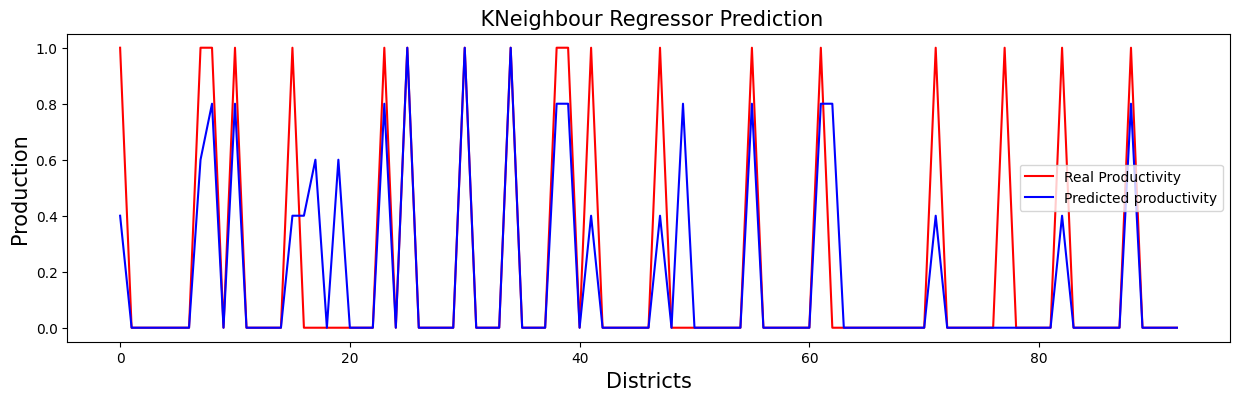

In [ ]:
#Visualising the results
plt.figure(figsize=(15,4))
plt.plot(y_test, color = 'red', label = 'Real Productivity')
plt.plot(y_pred_kn_2, color = 'blue', label = 'Predicted productivity')
plt.title(' KNeighbour Regressor Prediction',fontsize=15)
plt.xlabel('Districts',fontsize=15)
plt.ylabel('Production',fontsize=15)
plt.legend()
plt.show()

### RandomForest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf = RandomForestRegressor(n_estimators = 1000, random_state = 46)
rf.fit(X_train, y_train);

In [ ]:
rf_pred=rf.predict(X_test)
print('Mean squared Error:',mean_squared_error(y_test,rf_pred))
print('Root Mean Squared Error:',np.sqrt(mean_squared_error(y_test,rf_pred)))
#print('R2_Score:',r2_score(y_test,rf_pred))

Mean squared Error: 0.014803763440860212
Root Mean Squared Error: 0.12167071726944086


In [ ]:
randomforest_r2_score=r2_score(y_test,rf_pred)
randomforest_r2_score

0.9089347439544808

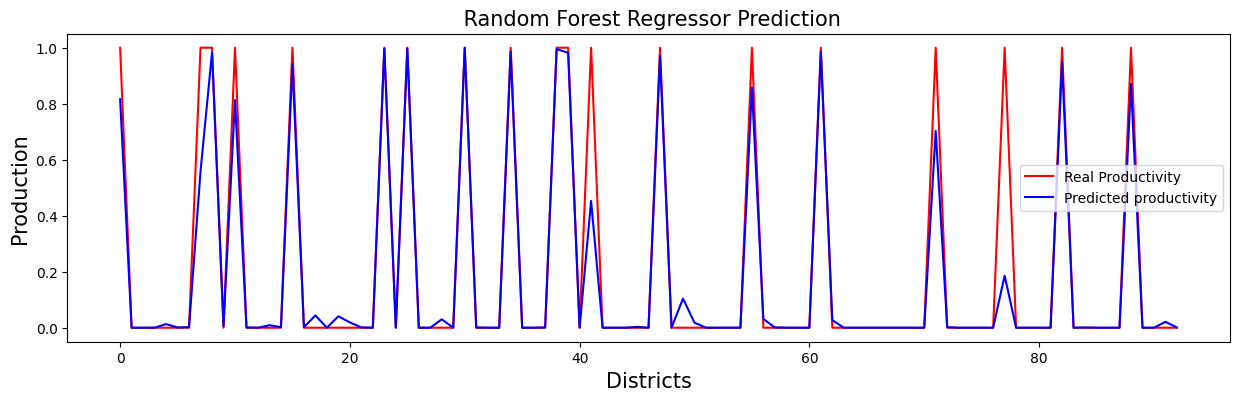

In [ ]:
#Visualising the results
plt.figure(figsize=(15,4))
plt.plot(y_test, color = 'red', label = 'Real Productivity')
plt.plot(rf_pred, color = 'blue', label = 'Predicted productivity')
plt.title(' Random Forest Regressor Prediction',fontsize=15)
plt.xlabel('Districts',fontsize=15)
plt.ylabel('Production',fontsize=15)
plt.legend()
plt.show()

In [ ]:
Regressors=['RandomForest','DesicionTree','KNeighbour']

In [ ]:
R2Score=[randomforest_r2_score,decision_r2_score,knn2_r2_score]

/tmp/ipykernel_1245/2059932953.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


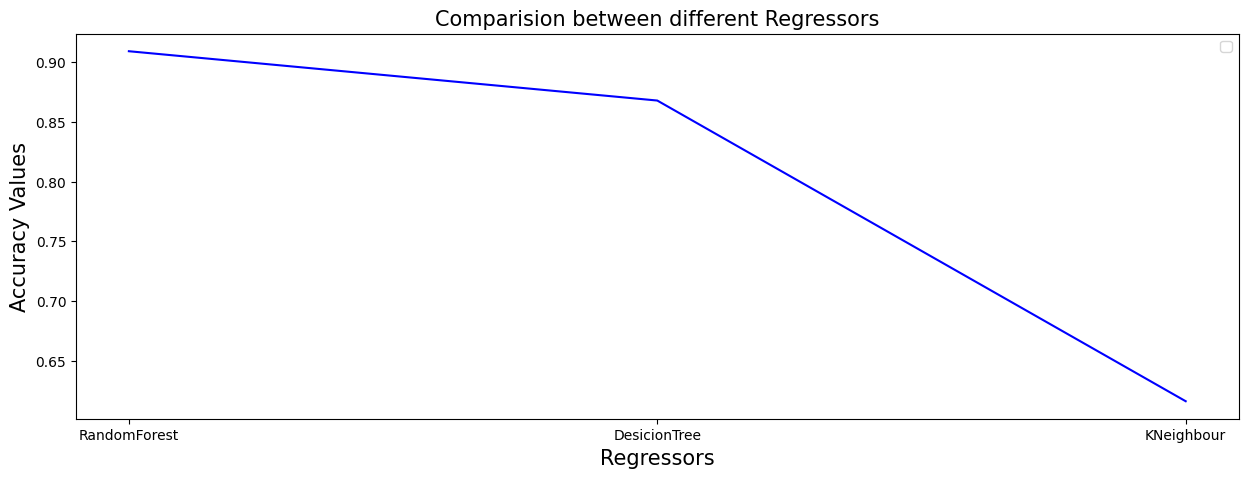

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(Regressors,R2Score, color = 'Blue')

plt.title('Comparision between different Regressors',fontsize=15)
plt.xlabel('Regressors',fontsize=15)
plt.ylabel('Accuracy Values',fontsize=15)
plt.legend()
plt.show()


# Part 4: Exportação e integração Via API ou CSV

In [ ]:
import pandas as pd

# 1. Monta a tabela unindo o valor real com o que as duas IAs previram
df_mvp = pd.DataFrame({
    'Produtividade_Real': y_test,
    'Previsao_Arvore_Decisao': y_pred_DT,
    'Previsao_KNN': y_pred_KNN
})

# 2. Salva no formato CSV pronto para o Power BI
# index=False evita criar uma coluna extra de números sem utilidade
df_mvp.to_csv('resultados_preditivos_mvp.csv', index=False)

print("🚀 Arquivo 'resultados_preditivos_mvp.csv' gerado com sucesso! Vá ao menu lateral para baixá-lo.")

🚀 Arquivo 'resultados_preditivos_mvp.csv' gerado com sucesso! Vá ao menu lateral para baixá-lo.
